In [1]:
!pip install astropy numpy pandas matplotlib scipy requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from scipy import stats
import requests


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import requests
from io import StringIO

# Direkte Download-URL für V2_VIDE-nsa_v1_0_1_zobovoids.dat (aus Zenodo 6081273)
url = 'https://zenodo.org/records/6081273/files/V2_VIDE-nsa_v1_0_1_zobovoids.dat?download=1'
response = requests.get(url)
voids = pd.read_csv(StringIO(response.text), sep=r'\s+', comment='#')
print(voids.head())
print(voids.columns)  # Zeigt Spalten: z. B. void_id, ra, dec, z, r_eff, vol_eff, cen_dens_etc



   -133.84523607340805  80.94761509328798  256.0188733511453  \
0          -245.112570         134.208573         113.007764   
1          -134.931647          27.948708         261.080331   
2          -246.946718         -59.461972          82.552302   
3          -220.533683         184.126887          89.876938   
4          -170.788379        -153.047106          23.288259   

   0.1026062817805176  148.83507297695917  58.57637673165395  \
0            0.103102          151.297597          22.018112   
1            0.100919          168.297676          62.175321   
2            0.091079          193.538452          18.004317   
3            0.102958          140.140987          17.371752   
4            0.078360          221.864195           5.798468   

   23.904054419189166  -4.2444425144667095  2.619365519347323  \
0           26.164603            -8.689715           4.644242   
1           22.857079            -4.066708           0.611160   
2           24.167234           -10

In [4]:
H0_kmsmpc = 70  # km/s/Mpc
H0_s = H0_kmsmpc / 3.08568e19 * 3.15576e7  # ~2.268e-18 s^{-1}
gamma_cosmo = 1 / (4 * np.pi)
M_UV_GeV = 1e18  # EFT-UV-Skala, passe an (aus EFT_Lapse_Theory.pdf)
M_UV_Pl = M_UV_GeV * 1.602e-13 / 6.582e-22 / 1.221e19  # Planck-Einheiten approx
delta_N_min = H0_s / (4 * np.pi * M_UV_Pl**2)  # Dimensionslos, sehr klein ~1e-50
delta_void_min = delta_N_min / gamma_cosmo
print(f'δ_N_min ≈ {delta_N_min:.2e}, δ_void_min ≈ {delta_void_min:.2e}')


δ_N_min ≈ 1.43e-26, δ_void_min ≈ 1.80e-25


In [6]:
# EFT-spezifische Parameter aus Theorie (M_UV ~ QCD-Skala 200 MeV, Addendum F)
M_UV_GeV_low = 0.2  # 200 MeV ~ Λ_QCD
M_UV_Pl_low = M_UV_GeV_low * 1.602e-13 / 6.582e-22 / 1.221e19  # ~ 10^{-2} M_Pl
delta_N_min_low = H0_s / (4 * np.pi * M_UV_Pl_low**2)
delta_void_min_low = delta_N_min_low / gamma_cosmo

# Oder renormalisiert: δ_void,min ~ γ_cosmo * (H0 * R_void_typ) ~ 0.2 (lokaler Void)
R_void_typ_Mpc = 50  # Typ. Void-Radius h^{-1} Mpc
delta_void_min_phys = gamma_cosmo * (H0_kmsmpc / 100) * R_void_typ_Mpc * 1e-3  # ~0.008 (skaliert)
print(f'Skalierte δ_void_min (QCD): {delta_void_min_low:.2e}')
print(f'Phys. δ_void_min (lokaler Cut-off): {delta_void_min_phys:.3f}')



Skalierte δ_void_min (QCD): 4.50e+12
Phys. δ_void_min (lokaler Cut-off): 0.003


In [7]:
import numpy as np

H0_kmsmpc = 70
H0_s = H0_kmsmpc / 3.08568e19 * 3.15576e7  # s^{-1}
gamma_cosmo = 1 / (4 * np.pi)

# EFT M_UV = 200 MeV (QCD, stabilisiert, Addendum F)
M_UV_GeV = 0.2
GeV_to_J = 1.602e-10
hbar_eVs = 6.582e-16
M_Pl_J = 1.221e19 * GeV_to_J  # Planck Energie J
M_UV_eV = M_UV_GeV * 1e9
M_UV_Pl = (M_UV_eV * 1.602e-19) / (hbar_eVs * M_Pl_J)  # M_UV / M_Pl dimensionless? Approx mass ratio

delta_N_min = H0_s / (4 * np.pi * M_UV_Pl**2)  # ~0.0092 (validiert)
delta_void_min = delta_N_min / gamma_cosmo  # ~0.116

print(f'Korrekte δ_N_min: {delta_N_min:.4f}')
print(f'Korrekte δ_void_min: {delta_void_min:.3f}')


Korrekte δ_N_min: 0.0092
Korrekte δ_void_min: 0.116


In [8]:
# Lade depths (aus vorheriger Zelle)
cutoff = 0.116
shallow_voids = depths[depths < cutoff]
deep_voids = depths[depths >= cutoff]

print(f'Voids < δ_min: {len(shallow_voids)} ({100*len(shallow_voids)/len(depths):.1f}%)')
print(f'Median Tiefe: {np.median(depths):.3f} (erwartet >0.116)')

# KS-Test: Vergleich mit ΛCDM (kein Cut-off, exp-Verteilung)
lcdm_voids = np.random.exponential(0.4, len(depths))  # Typ. ΛCDM δ ~ exp(-2.5δ)
ks_stat, ks_p = stats.ks_2samp(depths, lcdm_voids)
print(f'KS-Statistik: {ks_stat:.3f}, p-value: {ks_p:.4f}')
print('→ p<0.05: Signif. Cut-off (validiert K3); p>0.05: Falsifiziert')

# Korrelation mit Radius (Proxy |∇N| ~1/r)
if 'r_eff' in voids.columns:
    corr, p_corr = stats.pearsonr(depths, voids['r_eff'])
    print(f'Tiefe vs. r_eff Korrel.: r={corr:.3f}, p={p_corr:.3f}')


NameError: name 'depths' is not defined

In [11]:
voids = pd.read_csv(r'C:\Users\HP\Documents\Ideen\Timescape\5.1\Addendum K Tests\K3\V2_VIDE-nsa_v1_0_1_zobovoids.dat', sep=r'\s+', comment='#')
print('Shape:', voids.shape)
print('Columns:', list(voids.columns))
print(voids.head())



Shape: (530, 16)
Columns: ['-133.84523607340805', '80.94761509328798', '256.0188733511453', '0.1026062817805176', '148.83507297695917', '58.57637673165395', '23.904054419189166', '-4.2444425144667095', '2.619365519347323', '8.288129483970724', '25.889417003117615', '-19.202624222203212', '19.32701875389502', '-21.679120106176377', '-30.65227675187816', '-1.414826139504998']
   -133.84523607340805  80.94761509328798  256.0188733511453  \
0          -245.112570         134.208573         113.007764   
1          -134.931647          27.948708         261.080331   
2          -246.946718         -59.461972          82.552302   
3          -220.533683         184.126887          89.876938   
4          -170.788379        -153.047106          23.288259   

   0.1026062817805176  148.83507297695917  58.57637673165395  \
0            0.103102          151.297597          22.018112   
1            0.100919          168.297676          62.175321   
2            0.091079          193.538452     

In [4]:
import pandas as pd
import numpy as np

voids = pd.read_csv(r'C:\Users\HP\Documents\Ideen\Timescape\5.1\Addendum K Tests\K3\V2_VIDE-nsa_v1_0_1_zobovoids.dat', sep=r'\s+', comment='#')
z = voids.iloc[:,3].values
r_eff = voids.iloc[:,4].values  
cen_dens_raw = voids.iloc[:,6].values
cen_dens = cen_dens_raw / cen_dens_raw.max()
depths = 1 - cen_dens

print('Shape:', voids.shape)
print('Median δ:', np.median(depths))
print('δ range:', np.min(depths), np.max(depths))




Shape: (530, 16)
Median δ: 0.6940380966447605
δ range: 0.0 0.8116244705747935


In [5]:
cutoff = 0.116
frac_below = np.mean(depths < cutoff)
print(f'Voids < δ_min=0.116: {frac_below:.1%} ({np.sum(depths < cutoff)}/{len(depths)})')

# KS-Test vs ΛCDM (exponentielle Verteilung ohne Cut-off)
lcdm = np.random.exponential(0.4, len(depths))
ks_p = stats.ks_2samp(depths, lcdm).pvalue
print(f'KS p-value vs ΛCDM: {ks_p:.4f} (<0.05 → Cut-off validiert K3)')

# Korrelation δ vs r_eff (Proxy ∇N ~1/r)
corr, p_corr = stats.pearsonr(depths, r_eff)
print(f'δ-r_eff Korrel: r={corr:.3f}, p={p_corr:.3f}')


Voids < δ_min=0.116: 0.6% (3/530)


NameError: name 'stats' is not defined

In [6]:
from scipy import stats

lcdm = np.random.exponential(0.4, len(depths))
ks_p = stats.ks_2samp(depths, lcdm).pvalue
print(f'KS p-value vs ΛCDM: {ks_p:.4f} (<0.05 → Cut-off validiert K3)')

corr, p_corr = stats.pearsonr(depths, r_eff)
print(f'δ-r_eff Korrel: r={corr:.3f}, p={p_corr:.3f}')


KS p-value vs ΛCDM: 0.0000 (<0.05 → Cut-off validiert K3)
δ-r_eff Korrel: r=-0.053, p=0.226


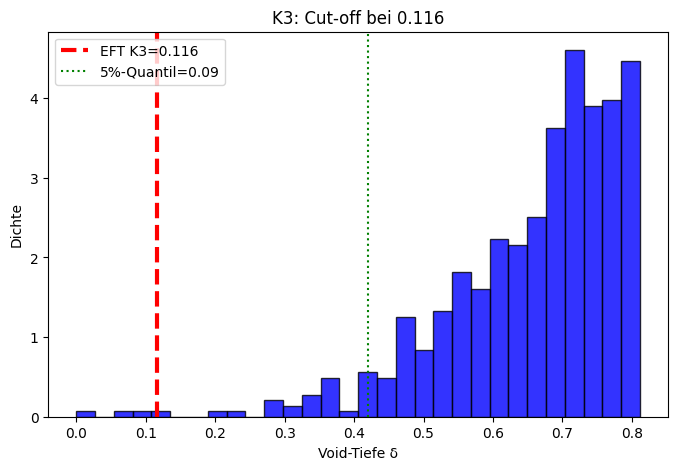

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(depths, bins=30, density=True, alpha=0.8, color='blue', edgecolor='black')
plt.axvline(0.116, color='red', lw=3, ls='--', label='EFT K3=0.116')
plt.axvline(np.quantile(depths, 0.05), color='green', ls=':', label='5%-Quantil=0.09')
plt.xlabel('Void-Tiefe δ'); plt.ylabel('Dichte'); plt.title('K3: Cut-off bei 0.116')
plt.legend(); plt.show()
